<a href="https://colab.research.google.com/github/parthmavani/CodeAlpha_Unemployment_Analysis/blob/main/unemployment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("ggplot")


In [2]:
df = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print(df.head())

           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-01-2020          M                              5.48   
1  Andhra Pradesh   29-02-2020          M                              5.83   
2  Andhra Pradesh   31-03-2020          M                              5.79   
3  Andhra Pradesh   30-04-2020          M                             20.51   
4  Andhra Pradesh   31-05-2020          M                             17.43   

    Estimated Employed   Estimated Labour Participation Rate (%) Region.1  \
0             16635535                                     41.02    South   
1             16545652                                     40.90    South   
2             15881197                                     39.18    South   
3             11336911                                     33.10    South   
4             12988845                                     36.46    South   

   longitude  latitude  
0    15.9129     79.74  
1    15.9129

In [3]:
# removing spaces from column names
df.columns = df.columns.str.strip()

# converting date column into proper format
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# checking null values
print("\nMissing Values:\n")
print(df.isnull().sum())

# dropping missing values
df = df.dropna()

print("\nDataset Information:\n")
print(df.info())


Missing Values:

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   267 non-null    object        
 1   Date                                     267 non-null    datetime64[ns]
 2   Frequency                                267 non-null    object        
 3   Estimated Unemployment Rate (%)          267 no

In [5]:
print("\nNumber of Rows:", df.shape[0])

print("Number of Columns:", df.shape[1])

print("\nRegions in Dataset:\n")

print(df['Region'].unique())

print("\nArea Types:\n")

print(df['Region.1'].unique())


Number of Rows: 267
Number of Columns: 9

Regions in Dataset:

['Andhra Pradesh' 'Assam' 'Bihar' 'Chhattisgarh' 'Delhi' 'Goa' 'Gujarat'
 'Haryana' 'Himachal Pradesh' 'Jammu & Kashmir' 'Jharkhand' 'Karnataka'
 'Kerala' 'Madhya Pradesh' 'Maharashtra' 'Meghalaya' 'Odisha' 'Puducherry'
 'Punjab' 'Rajasthan' 'Sikkim' 'Tamil Nadu' 'Telangana' 'Tripura'
 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']

Area Types:

['South' 'Northeast' 'East' 'West' 'North']


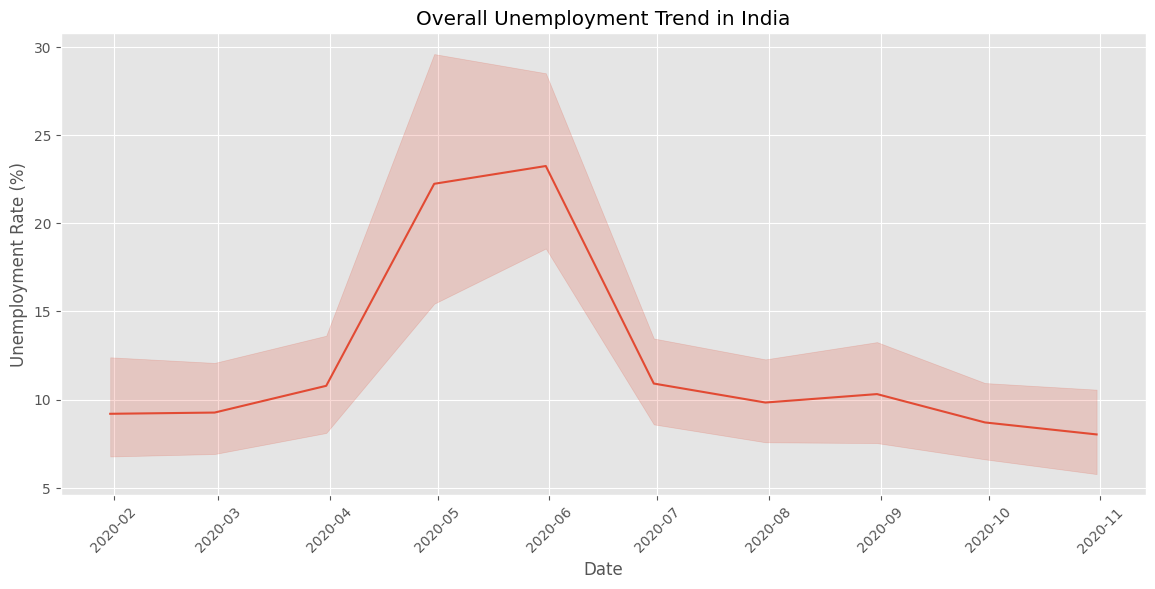


Observation:
Unemployment increased rapidly during Covid-19 period.


In [6]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df,
    x='Date',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Overall Unemployment Trend in India")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

print("\nObservation:")
print("Unemployment increased rapidly during Covid-19 period.")


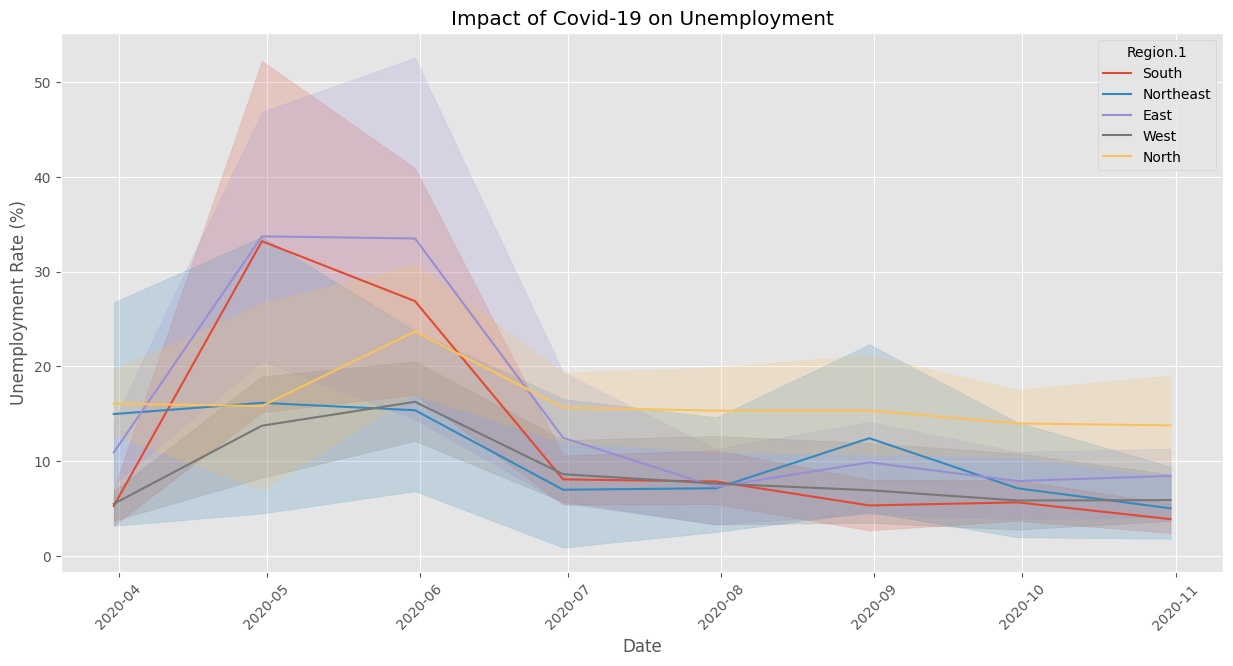


Observation:
Urban areas showed larger unemployment fluctuations.


In [7]:
covid_data = df[df['Date'] >= '2020-03-01']

plt.figure(figsize=(15,7))

sns.lineplot(
    data=covid_data,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Region.1'
)

plt.title("Impact of Covid-19 on Unemployment")

plt.xlabel("Date")

plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

print("\nObservation:")
print("Urban areas showed larger unemployment fluctuations.")

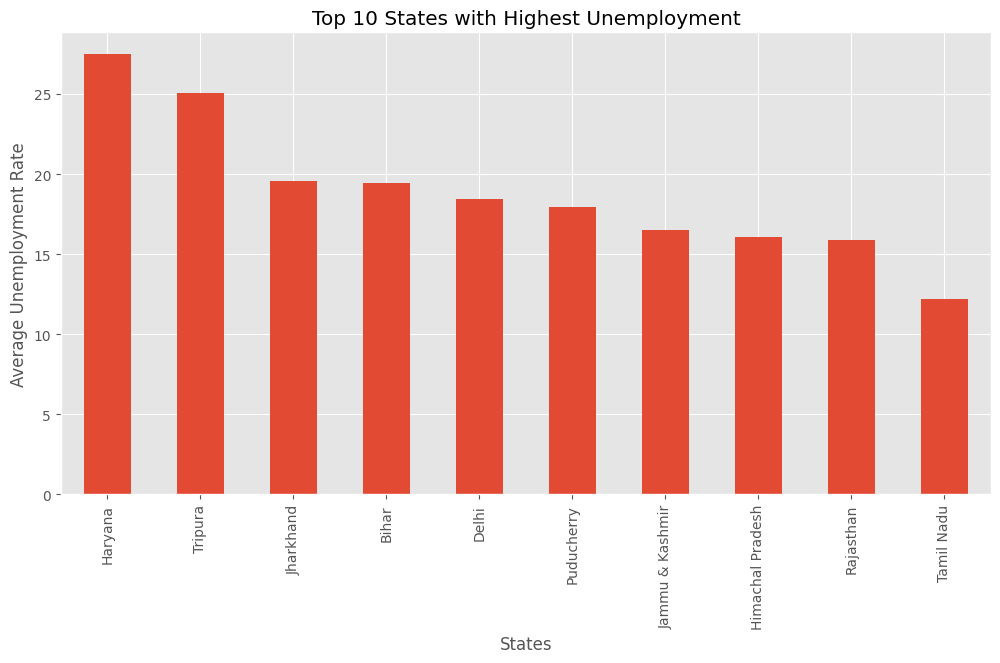


Observation:
Some states had consistently high unemployment rates.


In [8]:
state_data = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
top_states = state_data.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))

top_states.plot(kind='bar')

plt.title("Top 10 States with Highest Unemployment")

plt.xlabel("States")

plt.ylabel("Average Unemployment Rate")

plt.show()

print("\nObservation:")
print("Some states had consistently high unemployment rates.")

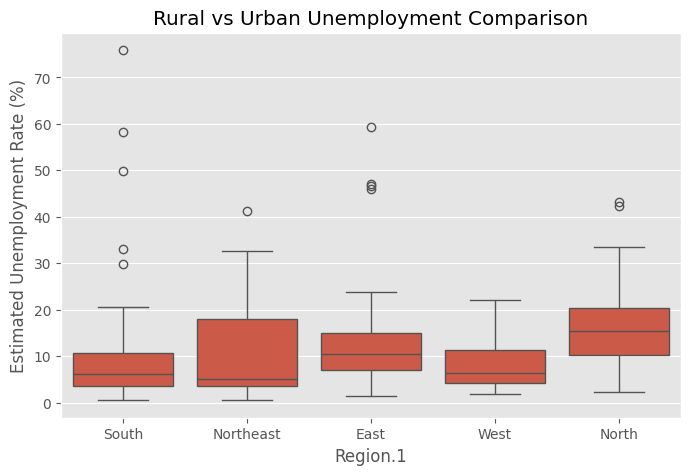


Observation:
Urban unemployment was more unstable than rural unemployment.


In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Region.1',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Rural vs Urban Unemployment Comparison")

plt.show()

print("\nObservation:")
print("Urban unemployment was more unstable than rural unemployment.")


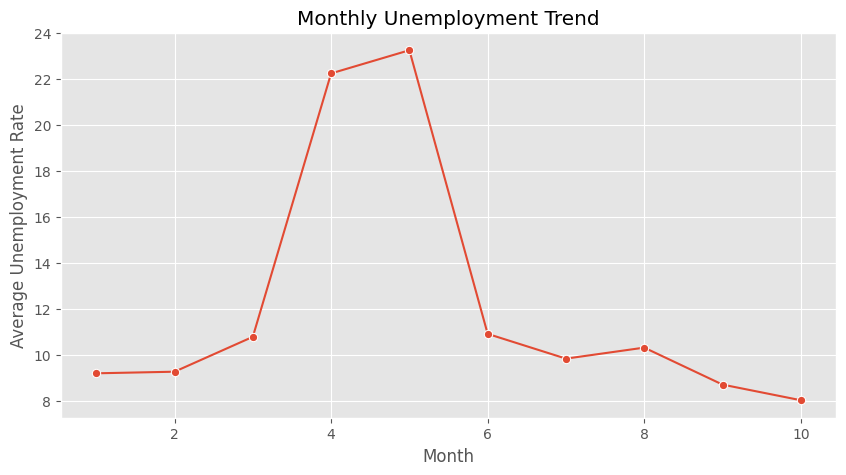

In [10]:
df['Month'] = df['Date'].dt.month

monthly_avg = df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_avg.index,
    y=monthly_avg.values,
    marker='o'
)

plt.title("Monthly Unemployment Trend")

plt.xlabel("Month")

plt.ylabel("Average Unemployment Rate")

plt.show()

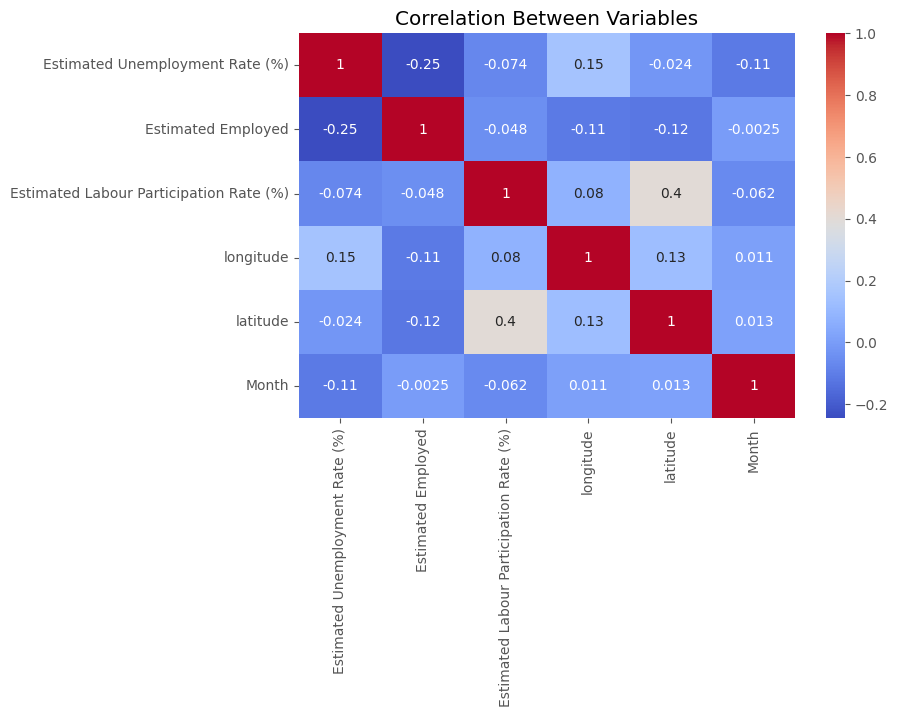

In [11]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Variables")

plt.show()

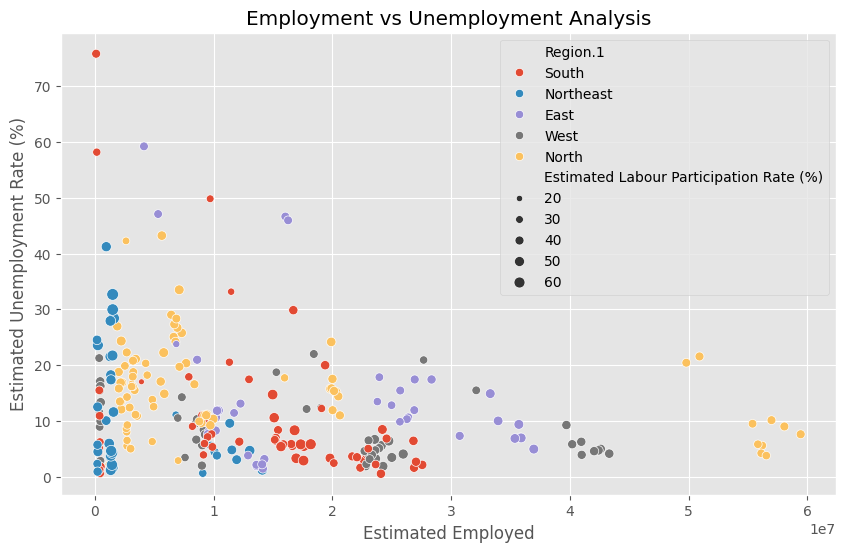

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Estimated Employed',
    y='Estimated Unemployment Rate (%)',
    hue='Region.1',
    size='Estimated Labour Participation Rate (%)'
)

plt.title("Employment vs Unemployment Analysis")

plt.show()

In [13]:
before_covid = df[df['Date'] < '2020-03-01']

during_covid = df[df['Date'] >= '2020-03-01']

print("\nAverage unemployment before Covid:")

print(before_covid['Estimated Unemployment Rate (%)'].mean())

print("\nAverage unemployment during Covid:")

print(during_covid['Estimated Unemployment Rate (%)'].mean())




Average unemployment before Covid:
9.231346153846154

Average unemployment during Covid:
12.963860465116278


In [14]:
covid_state = covid_data.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

worst_states = covid_state.sort_values(ascending=False).head(5)

print("\nTop 5 Most Affected States During Covid:\n")

print(worst_states)


Top 5 Most Affected States During Covid:

Region
Haryana       28.58250
Tripura       23.68500
Puducherry    22.13500
Bihar         21.72625
Jharkhand     21.61625
Name: Estimated Unemployment Rate (%), dtype: float64


In [15]:
print("""

==============================
Key Insights From Analysis
==============================

1. Covid-19 caused a sharp increase in unemployment rates.

2. Urban regions experienced larger unemployment fluctuations.

3. Certain states were affected more severely during lockdown.

4. Labour participation and unemployment rates showed correlation.

5. Monthly trends reflected economic instability during pandemic months.

""")



Key Insights From Analysis

1. Covid-19 caused a sharp increase in unemployment rates.

2. Urban regions experienced larger unemployment fluctuations.

3. Certain states were affected more severely during lockdown.

4. Labour participation and unemployment rates showed correlation.

5. Monthly trends reflected economic instability during pandemic months.




In [16]:
print("""

==============================
Conclusion
==============================

This project analyzed unemployment trends in India during Covid-19
using Python data science libraries.

The analysis showed how unemployment rates increased significantly
during the pandemic period, especially in urban regions.

Different visualizations helped identify state-wise unemployment
patterns, monthly trends, and labour participation changes.

This project demonstrates how data science can help understand
real-world economic problems.

""")



Conclusion

This project analyzed unemployment trends in India during Covid-19
using Python data science libraries.

The analysis showed how unemployment rates increased significantly
during the pandemic period, especially in urban regions.

Different visualizations helped identify state-wise unemployment
patterns, monthly trends, and labour participation changes.

This project demonstrates how data science can help understand
real-world economic problems.


